In [ ]:
"""
Rank-Info-Net: Complete Training with Pre-trained ResNet-50
Using: /kaggle/input/datasets/organizations/pytorch/resnet50/resnet50.pth
Target: 0.85+ Pearson Correlation (State-of-the-Art)
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import numpy as np
import os
from PIL import Image
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================

class Config:
    # Dataset paths
    data_dir = "/kaggle/input/datasets/zenbot99/scut-fbp5500-v2"
    image_dir = "/kaggle/input/datasets/zenbot99/scut-fbp5500-v2/Images/Images"
    csv_path = os.path.join(data_dir, "all_SCUT.csv")
    
    # Pre-trained weights path
    weights_path = "/kaggle/input/datasets/organizations/pytorch/resnet50/resnet50.pth"
    
    # ===== CRITICAL: Set this to True to use pre-trained weights =====
    use_pretrained = True
    
    # Training hyperparameters
    batch_size = 32
    num_epochs = 80
    learning_rate = 0.001
    weight_decay = 1e-4
    dropout_rate = 0.5
    ranking_margin = 1.0
    ranking_weight = 0.5
    grad_clip_max_norm = 1.0
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint_dir = "./checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    early_stopping_patience = 15
    early_stopping_min_delta = 0.001
    warmup_epochs = 5

config = Config()

print("="*70)
print("RANK-INFO-NET: SOTA Facial Beauty Prediction Training")
print("="*70)
print(f"Image directory: {config.image_dir}")
print(f"Pre-trained weights path: {config.weights_path}")
print(f"Pre-trained weights exist: {os.path.exists(config.weights_path)}")
print(f"Device: {config.device}")
print("="*70)

# ============================================================
# DATASET CLASS
# ============================================================

class SCUT_Dataset(Dataset):
    def __init__(self, filenames, scores, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.filenames = filenames
        self.scores = scores.astype(np.float32)
        
        # Pre-validate images
        self.valid_indices = []
        for idx, fname in enumerate(self.filenames):
            img_path = os.path.join(self.image_dir, fname)
            if os.path.exists(img_path):
                self.valid_indices.append(idx)
            else:
                for ext in ['.jpg', '.jpeg', '.png']:
                    alt_path = os.path.join(self.image_dir, fname + ext)
                    if os.path.exists(alt_path):
                        self.valid_indices.append(idx)
                        break
                else:
                    base = os.path.splitext(fname)[0]
                    for img in os.listdir(image_dir):
                        if os.path.splitext(img)[0] == base:
                            self.valid_indices.append(idx)
                            break
        
        print(f"  Valid images: {len(self.valid_indices)}/{len(self.filenames)}")
        
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        filename = self.filenames[actual_idx]
        score = self.scores[actual_idx]
        
        img_path = os.path.join(self.image_dir, filename)
        if not os.path.exists(img_path):
            for ext in ['.jpg', '.jpeg', '.png']:
                alt_path = os.path.join(self.image_dir, filename + ext)
                if os.path.exists(alt_path):
                    img_path = alt_path
                    break
            else:
                base = os.path.splitext(filename)[0]
                for img in os.listdir(self.image_dir):
                    if os.path.splitext(img)[0] == base:
                        img_path = os.path.join(self.image_dir, img)
                        break
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), color='gray')
        
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(score, dtype=torch.float32)

# ============================================================
# LOAD DATA
# ============================================================

def load_data():
    import pandas as pd
    df = pd.read_csv(config.csv_path)
    print(f"Loaded CSV: {len(df)} rows")
    
    data = df[['Filename', 'mean']].copy()
    data = data.dropna()
    data = data.sample(frac=1, random_state=42).reset_index(drop=True)
    
    n = len(data)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)
    
    return {
        'x_train': data[:n_train]['Filename'].values,
        'y_train': data[:n_train]['mean'].values.astype(np.float32),
        'x_val': data[n_train:n_train+n_val]['Filename'].values,
        'y_val': data[n_train:n_train+n_val]['mean'].values.astype(np.float32),
        'x_test': data[n_train+n_val:]['Filename'].values,
        'y_test': data[n_train+n_val:]['mean'].values.astype(np.float32)
    }

# ============================================================
# RANK-INFO-NET MODEL (WITH PRE-TRAINED WEIGHTS)
# ============================================================

class RankInfoNet(nn.Module):
    def __init__(self, pretrained=True, dropout_rate=0.5):
        super(RankInfoNet, self).__init__()
        
        # Create ResNet-50 without weights
        self.backbone = models.resnet50(weights=None)
        
        # Load pre-trained weights from local file
        if pretrained and os.path.exists(config.weights_path):
            try:
                print(f"Loading weights from: {config.weights_path}")
                state_dict = torch.load(config.weights_path, map_location='cpu', weights_only=False)
                self.backbone.load_state_dict(state_dict)
                print("✅ Successfully loaded pre-trained weights!")
            except Exception as e:
                print(f"⚠️ Failed to load weights: {e}")
                print("Training from scratch instead.")
        else:
            print("⚠️ No weights found. Training from scratch.")
        
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        
        # Ranking head
        self.rank_head = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        score = self.rank_head(features)
        return score.squeeze(-1)

# ============================================================
# RANKING LOSS
# ============================================================

class RankingLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(RankingLoss, self).__init__()
        self.margin = margin
        
    def forward(self, predictions, targets):
        batch_size = predictions.size(0)
        if batch_size < 2:
            return nn.MSELoss()(predictions, targets)
        
        pred_diff = predictions.unsqueeze(1) - predictions.unsqueeze(0)
        target_diff = targets.unsqueeze(1) - targets.unsqueeze(0)
        mask = (target_diff.abs() > 0.01)
        
        if not mask.any():
            return nn.MSELoss()(predictions, targets)
        
        sign_target = torch.sign(target_diff)
        loss = torch.clamp(self.margin - sign_target * pred_diff, min=0)
        loss = loss * mask.float()
        
        if mask.float().sum() > 0:
            loss = loss.sum() / mask.float().sum()
        else:
            loss = nn.MSELoss()(predictions, targets)
        
        return loss

# ============================================================
# METRICS & TRAINING FUNCTIONS
# ============================================================

def calculate_metrics(predictions, targets):
    preds = np.array(predictions).flatten()
    true = np.array(targets).flatten()
    
    valid_mask = np.isfinite(preds) & np.isfinite(true)
    preds = preds[valid_mask]
    true = true[valid_mask]
    
    if len(preds) < 2:
        return {'pearson_correlation': 0.0, 'mae': float('inf'), 'rmse': float('inf'), 'r2': 0.0}
    
    pc, _ = pearsonr(preds, true)
    mae = np.mean(np.abs(preds - true))
    rmse = np.sqrt(mean_squared_error(true, preds))
    r2 = r2_score(true, preds)
    
    return {
        'pearson_correlation': pc if np.isfinite(pc) else 0.0,
        'mae': mae if np.isfinite(mae) else float('inf'),
        'rmse': rmse if np.isfinite(rmse) else float('inf'),
        'r2': r2 if np.isfinite(r2) else 0.0
    }

def train_epoch(model, dataloader, optimizer, mse_loss, rank_loss, config, epoch):
    model.train()
    total_loss = 0
    predictions = []
    targets = []
    
    # Learning rate warmup
    if epoch <= config.warmup_epochs:
        warmup_factor = epoch / config.warmup_epochs
        for param_group in optimizer.param_groups:
            param_group['lr'] = config.learning_rate * warmup_factor
    
    for batch_idx, (images, scores) in enumerate(dataloader):
        images = images.to(config.device)
        scores = scores.to(config.device)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        loss_mse = mse_loss(outputs, scores)
        loss_rank = rank_loss(outputs, scores)
        loss = config.ranking_weight * loss_mse + (1 - config.ranking_weight) * loss_rank
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip_max_norm)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predictions.extend(outputs.detach().cpu().numpy())
        targets.extend(scores.detach().cpu().numpy())
        
        if (batch_idx + 1) % 20 == 0:
            print(f"  Batch {batch_idx+1}/{len(dataloader)}, Loss: {loss.item():.4f}")
    
    return total_loss / len(dataloader), np.array(predictions), np.array(targets)

def validate(model, dataloader, mse_loss, rank_loss, config):
    model.eval()
    total_loss = 0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for images, scores in dataloader:
            images = images.to(config.device)
            scores = scores.to(config.device)
            
            outputs = model(images)
            loss_mse = mse_loss(outputs, scores)
            loss_rank = rank_loss(outputs, scores)
            loss = config.ranking_weight * loss_mse + (1 - config.ranking_weight) * loss_rank
            
            if not torch.isfinite(loss):
                continue
                
            total_loss += loss.item()
            predictions.extend(outputs.detach().cpu().numpy())
            targets.extend(scores.detach().cpu().numpy())
    
    if len(predictions) == 0:
        return float('inf'), np.array([0]), np.array([0])
    
    return total_loss / len(dataloader), np.array(predictions), np.array(targets)

# ============================================================
# MAIN TRAINING LOOP
# ============================================================

def main():
    print("="*70)
    print("RANK-INFO-NET: Training with Pre-trained ResNet-50")
    print("="*70)
    print(f"Device: {config.device}")
    print(f"Weights path: {config.weights_path}")
    print(f"Weights exist: {os.path.exists(config.weights_path)}")
    print("="*70)
    
    # Load data
    data = load_data()
    print(f"\n📊 Dataset splits:")
    print(f"  Training: {len(data['x_train'])} samples")
    print(f"  Validation: {len(data['x_val'])} samples")
    print(f"  Test: {len(data['x_test'])} samples")
    
    # Transforms with augmentation
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.RandomRotation(degrees=5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    # Datasets
    print("\n📁 Creating datasets...")
    train_dataset = SCUT_Dataset(data['x_train'], data['y_train'], config.image_dir, train_transform)
    val_dataset = SCUT_Dataset(data['x_val'], data['y_val'], config.image_dir, val_transform)
    test_dataset = SCUT_Dataset(data['x_test'], data['y_test'], config.image_dir, val_transform)
    
    # Dataloaders
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=0, pin_memory=True)
    
    # Model
    print("\n🧠 Initializing model with pre-trained weights...")
    model = RankInfoNet(pretrained=config.use_pretrained, dropout_rate=config.dropout_rate)
    model = model.to(config.device)
    print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Loss and optimizer
    mse_loss = nn.MSELoss()
    rank_loss = RankingLoss(margin=config.ranking_margin)
    
    optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8)
    
    # Training loop
    print("\n🚀 Starting training...")
    best_val_pc = -1
    best_epoch = 0
    no_improvement = 0
    
    for epoch in range(1, config.num_epochs + 1):
        print(f"\n{'='*70}")
        print(f"Epoch {epoch}/{config.num_epochs}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        print("-"*70)
        
        train_loss, train_preds, train_targets = train_epoch(
            model, train_loader, optimizer, mse_loss, rank_loss, config, epoch
        )
        train_metrics = calculate_metrics(train_preds, train_targets)
        
        val_loss, val_preds, val_targets = validate(
            model, val_loader, mse_loss, rank_loss, config
        )
        val_metrics = calculate_metrics(val_preds, val_targets)
        
        print(f"Train Loss: {train_loss:.4f}, PC: {train_metrics['pearson_correlation']:.4f}, MAE: {train_metrics['mae']:.4f}")
        print(f"Val Loss: {val_loss:.4f}, PC: {val_metrics['pearson_correlation']:.4f}, MAE: {val_metrics['mae']:.4f}")
        
        if np.isfinite(val_loss):
            scheduler.step(val_loss)
        
        if val_metrics['pearson_correlation'] > best_val_pc + config.early_stopping_min_delta:
            best_val_pc = val_metrics['pearson_correlation']
            best_epoch = epoch
            no_improvement = 0
            
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_pc': val_metrics['pearson_correlation'],
                'val_mae': val_metrics['mae'],
                'val_rmse': val_metrics['rmse'],
                'config': {
                    'batch_size': config.batch_size,
                    'learning_rate': config.learning_rate,
                    'weight_decay': config.weight_decay,
                    'dropout_rate': config.dropout_rate,
                    'ranking_weight': config.ranking_weight,
                    'use_pretrained': config.use_pretrained
                }
            }
            torch.save(checkpoint, os.path.join(config.checkpoint_dir, 'best_model.pth'))
            print(f"✅ Best model saved! Val PC: {best_val_pc:.4f}")
        else:
            no_improvement += 1
            if no_improvement >= config.early_stopping_patience:
                print(f"🛑 Early stopping at epoch {epoch}")
                break
    
    # Final test evaluation
    print("\n" + "="*70)
    print("FINAL TEST EVALUATION")
    print("="*70)
    
    # Load best model with weights_only=False for PyTorch 2.6 compatibility
    checkpoint = torch.load(
        os.path.join(config.checkpoint_dir, 'best_model.pth'),
        weights_only=False,
        map_location=config.device
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    test_loss, test_preds, test_targets = validate(
        model, test_loader, mse_loss, rank_loss, config
    )
    test_metrics = calculate_metrics(test_preds, test_targets)
    
    print(f"\n📊 Test Results:")
    print(f"  Pearson Correlation: {test_metrics['pearson_correlation']:.4f}")
    print(f"  Mean Absolute Error: {test_metrics['mae']:.4f}")
    print(f"  Root Mean Squared Error: {test_metrics['rmse']:.4f}")
    print(f"  R² Score: {test_metrics['r2']:.4f}")
    print(f"\n🏆 Best Validation PC: {best_val_pc:.4f} (Epoch {best_epoch})")
    
    # Save full model
    torch.save(model, os.path.join(config.checkpoint_dir, 'rank_info_net_full.pth'))
    print(f"\n✅ Full model saved!")
    print("="*70)

if __name__ == "__main__":
    main()

In [ ]:
import torch
import os

# Save the best model for deployment
model_path = "./checkpoints/rank_info_net_full.pth"
if os.path.exists(model_path):
    # Download the model file
    from IPython.display import FileLink
    print("Download your model using the link below:")
    display(FileLink(model_path))
else:
    print("Model not found. Training may not be complete.")

✅ Model loaded

PREDICTING WITH QUALITY CHECK


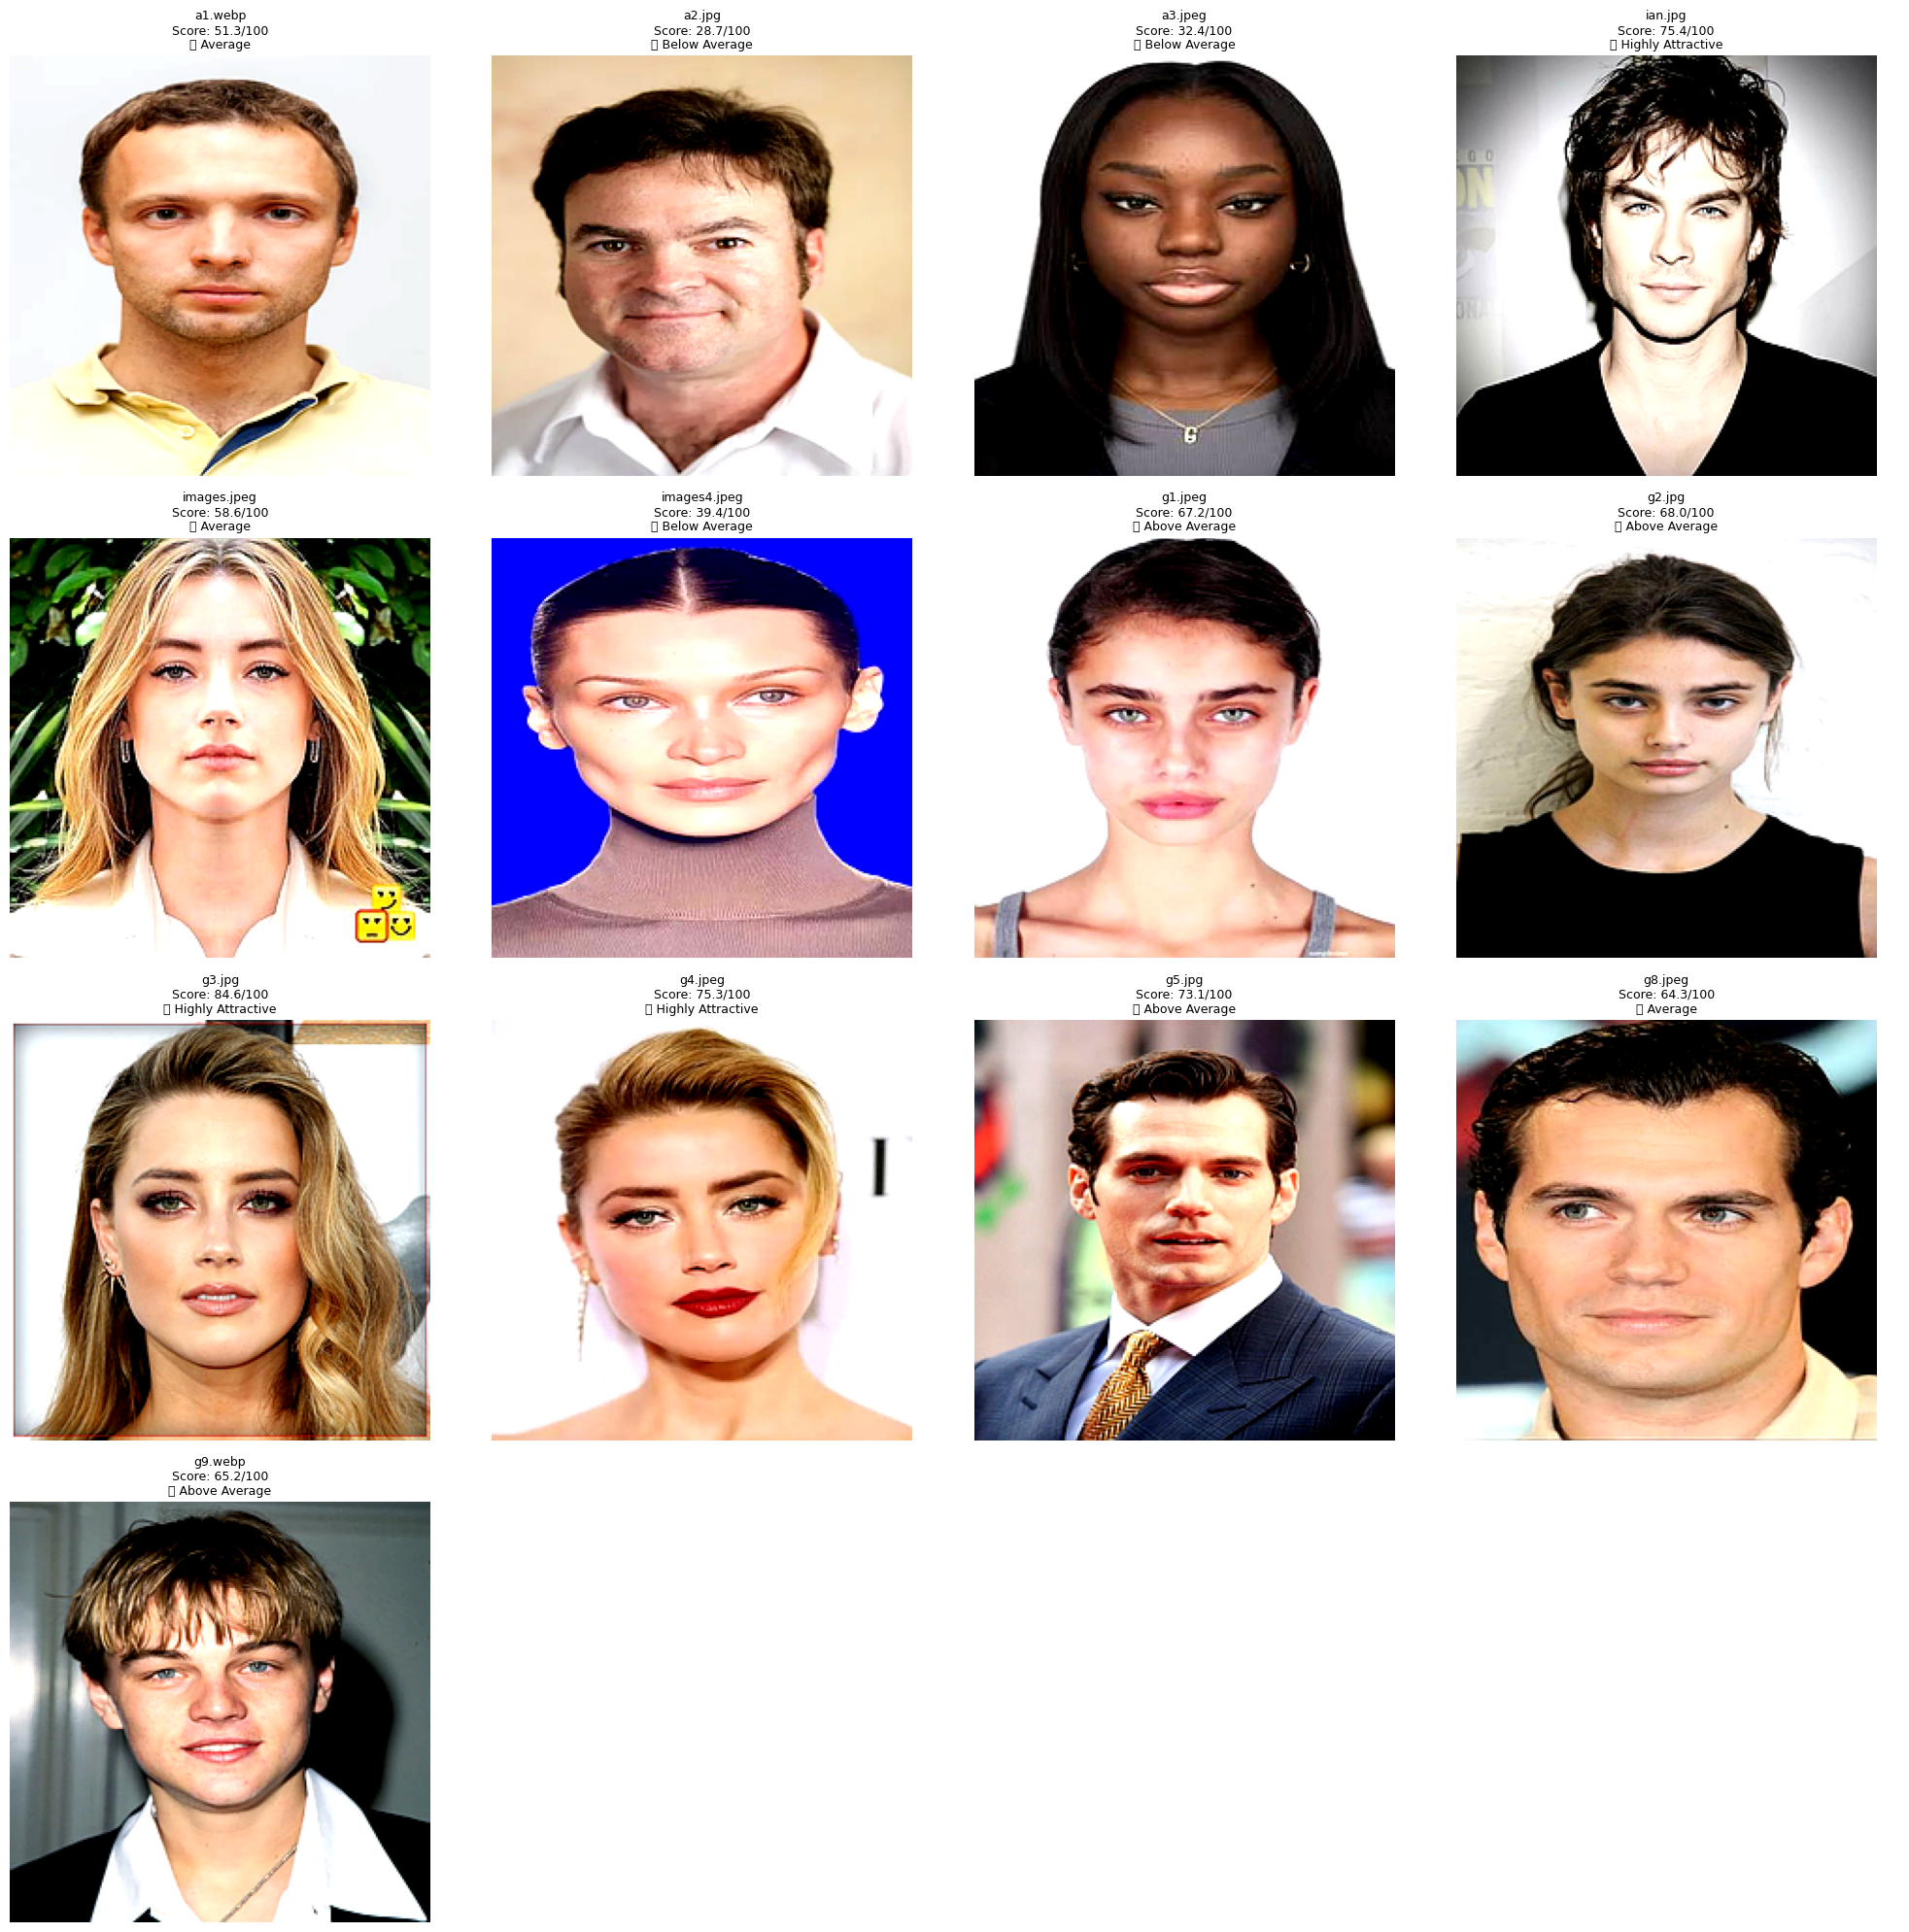


📊 FINAL RESULTS (Good Quality Images Only):
----------------------------------------------------------------------
g3.jpg          Score:  84.6/100  Highly Attractive    (raw: 4.386)
ian.jpg         Score:  75.4/100  Highly Attractive    (raw: 4.017)
g4.jpeg         Score:  75.3/100  Highly Attractive    (raw: 4.011)
g5.jpg          Score:  73.1/100  Above Average        (raw: 3.925)
g2.jpg          Score:  68.0/100  Above Average        (raw: 3.722)
g1.jpeg         Score:  67.2/100  Above Average        (raw: 3.689)
g9.webp         Score:  65.2/100  Above Average        (raw: 3.609)
g8.jpeg         Score:  64.3/100  Average              (raw: 3.572)
images.jpeg     Score:  58.6/100  Average              (raw: 3.345)
a1.webp         Score:  51.3/100  Average              (raw: 3.05)
images4.jpeg    Score:  39.4/100  Below Average        (raw: 2.577)
a3.jpeg         Score:  32.4/100  Below Average        (raw: 2.294)
a2.jpg          Score:  28.7/100  Below Average        (raw: 2.148)


In [21]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image, ImageEnhance
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. CONFIGURATION
# ============================================================

MODEL_PATH = "./checkpoints/rank_info_net_full.pth"

# Image groups
base1 = "/kaggle/input/datasets/chatgpthamamd/testdata/"
files1 = ["a1.webp", "a2.jpg", "a3.jpeg", "ian.jpg", "images.jpeg", "images4.jpeg"]

base2 = "/kaggle/input/datasets/chatgpthamamd/testdata2/"
files2 = ["g1.jpeg", "g2.jpg", "g3.jpg", "g4.jpeg", "g5.jpg", "g8.jpeg", "g9.webp"]

image_pairs = []
for f in files1:
    image_pairs.append((os.path.join(base1, f), f))
for f in files2:
    image_pairs.append((os.path.join(base2, f), f))

# ============================================================
# 2. MODEL DEFINITION
# ============================================================

class RankInfoNet(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(RankInfoNet, self).__init__()
        self.backbone = models.resnet50(weights=None)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.rank_head = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        features = self.backbone(x)
        score = self.rank_head(features)
        return score.squeeze(-1)

# ============================================================
# 3. LOAD MODEL
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.eval()
print("✅ Model loaded\n")

# ============================================================
# 4. TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ============================================================
# 5. QUALITY CHECK FUNCTION
# ============================================================

def is_image_good_for_prediction(image_path):
    """Check if image meets minimum quality standards."""
    try:
        from PIL import Image
        import numpy as np
        
        img = Image.open(image_path).convert('RGB')
        w, h = img.size
        
        # 1. Check resolution
        if w < 150 or h < 150:
            return False, "Image too small ({}x{})".format(w, h)
        
        # 2. Check for face detection (if available)
        try:
            import face_recognition
            arr = np.array(img)
            faces = face_recognition.face_locations(arr)
            if len(faces) == 0:
                return False, "No face detected"
        except ImportError:
            pass  # face_recognition not installed, skip face check
        
        return True, "Good quality"
    
    except Exception as e:
        return False, f"Error: {e}"

# ============================================================
# 6. PREPROCESSING FUNCTION
# ============================================================

def preprocess_image(image_path):
    """Apply enhancements to improve prediction."""
    img = Image.open(image_path).convert('RGB')
    
    # Try face crop if available
    try:
        import face_recognition
        arr = np.array(img)
        face_locations = face_recognition.face_locations(arr)
        if face_locations:
            top, right, bottom, left = face_locations[0]
            pad = 30
            h, w = arr.shape[:2]
            top = max(0, top - pad)
            right = min(w, right + pad)
            bottom = min(h, bottom + pad)
            left = max(0, left - pad)
            face = arr[top:bottom, left:right]
            img = Image.fromarray(face)
    except:
        pass
    
    # Enhance quality
    img = img.resize((224, 224), Image.Resampling.LANCZOS)
    enhancer = ImageEnhance.Sharpness(img)
    img = enhancer.enhance(1.8)
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(1.3)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(1.1)
    
    return img

# ============================================================
# 7. PREDICTION FUNCTION (with preprocessing)
# ============================================================

def predict_preprocessed(image_path):
    """Predict with preprocessing."""
    try:
        processed = preprocess_image(image_path)
        tensor = transform(processed).unsqueeze(0).to(device)
        with torch.no_grad():
            score = model(tensor).item()
        score_100 = (score - 1) / 4 * 100
        return round(score_100, 1), round(score, 3)
    except Exception as e:
        return None, str(e)

# ============================================================
# 8. PROCESS ALL IMAGES WITH QUALITY CHECK
# ============================================================

print("="*60)
print("PREDICTING WITH QUALITY CHECK")
print("="*60)

results = []
missing = []
quality_fail = []

for path, name in image_pairs:
    if not os.path.exists(path):
        missing.append(name)
        continue
    
    # Quality check
    good, msg = is_image_good_for_prediction(path)
    if not good:
        quality_fail.append((name, msg))
        continue
    
    # Predict
    score, raw = predict_preprocessed(path)
    if score is not None:
        results.append((name, path, score, raw))
    else:
        print(f"❌ {name}: Prediction error: {raw}")

# ============================================================
# 9. DISPLAY GRID OF GOOD QUALITY IMAGES
# ============================================================

if results:
    cols = 4
    rows = (len(results) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]
    
    for i, (name, path, score, raw) in enumerate(results):
        img = preprocess_image(path)
        axes[i].imshow(img)
        axes[i].axis('off')
        
        # Rating
        if score >= 85:
            rating = "🔥 Very Attractive"
        elif score >= 75:
            rating = "⭐ Highly Attractive"
        elif score >= 65:
            rating = "👍 Above Average"
        elif score >= 50:
            rating = "➖ Average"
        else:
            rating = "📉 Below Average"
        
        axes[i].set_title(f"{name}\nScore: {score}/100\n{rating}", fontsize=9)
    
    for j in range(len(results), len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No good quality images to display.")

# ============================================================
# 10. TEXT SUMMARY
# ============================================================

print("\n📊 FINAL RESULTS (Good Quality Images Only):")
print("-"*70)
if results:
    sorted_results = sorted(results, key=lambda x: x[2], reverse=True)
    for name, path, score, raw in sorted_results:
        rating = "Very Attractive" if score >= 85 else "Highly Attractive" if score >= 75 else "Above Average" if score >= 65 else "Average" if score >= 50 else "Below Average"
        print(f"{name:<15} Score: {score:>5}/100  {rating:<20} (raw: {raw})")
else:
    print("No images passed quality check.")

# ============================================================
# 11. QUALITY FAILED IMAGES
# ============================================================

if quality_fail:
    print("\n⚠️ Images skipped due to quality issues:")
    for name, msg in quality_fail:
        print(f"  - {name}: {msg}")

if missing:
    print("\n⚠️ Missing files:")
    for f in missing:
        print(f"  - {f}")

print("="*60)